In [1]:
# STEP 1: Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# STEP 2: Load Dataset
digits = load_digits()
X = digits.data
y = digits.target

print(f"Total images: {X.shape[0]}")
print(f"Features per image: {X.shape[1]}")
print(f"Image shape: 8x8 pixels")
print(f"Classes (digits): {list(np.unique(y))}")
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print("✅ Dataset loaded!")

Total images: 1797
Features per image: 64
Image shape: 8x8 pixels
Classes (digits): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

X shape: (1797, 64)
y shape: (1797,)
✅ Dataset loaded!


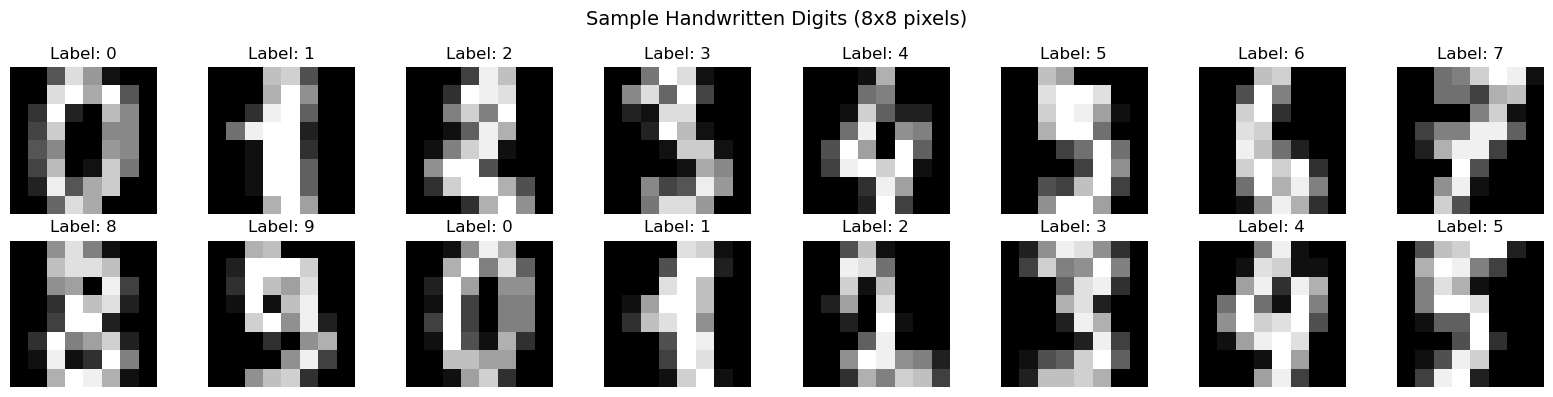

✅ Sample images displayed!


In [3]:
# STEP 3: Visualize Sample Digit Images
fig, axes = plt.subplots(2, 8, figsize=(16, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Label: {y[i]}")
    ax.axis('off')

plt.suptitle("Sample Handwritten Digits (8x8 pixels)", fontsize=14)
plt.tight_layout()
plt.show()
print("✅ Sample images displayed!")

In [4]:
# STEP 4: Split & Scale the Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training images:  {X_train_scaled.shape[0]}")
print(f"Testing images:   {X_test_scaled.shape[0]}")
print(f"Features each:    {X_train_scaled.shape[1]}")
print("✅ Data split and scaled!")

Training images:  1437
Testing images:   360
Features each:    64
✅ Data split and scaled!


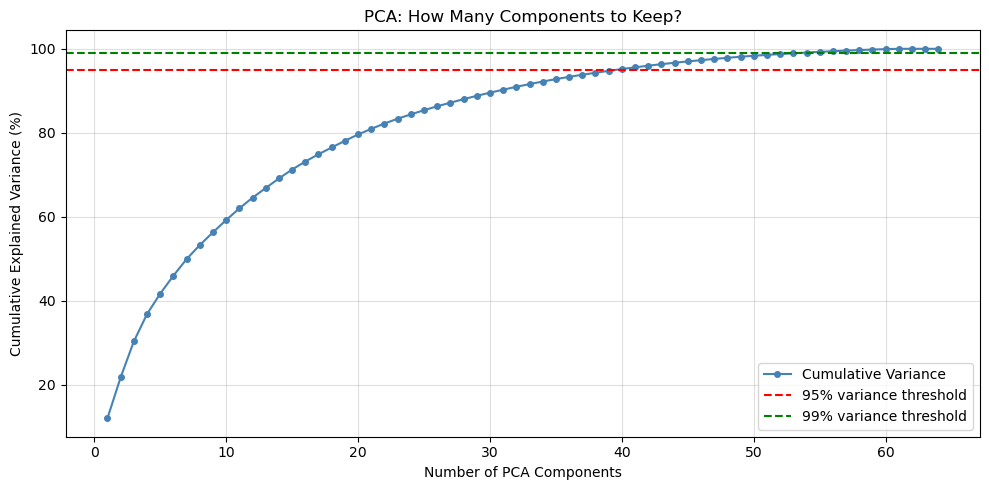

To retain 80% variance → need 21 components
To retain 90% variance → need 31 components
To retain 95% variance → need 40 components
To retain 99% variance → need 54 components
✅ Variance curve displayed!


In [5]:
# STEP 5: PCA Cumulative Explained Variance Curve
pca_full = PCA(n_components=64)
pca_full.fit(X_train_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100

plt.figure(figsize=(10, 5))
plt.plot(range(1, 65), cumvar, marker='o', markersize=4, color='steelblue', label='Cumulative Variance')
plt.axhline(y=95, color='red', linestyle='--', linewidth=1.5, label='95% variance threshold')
plt.axhline(y=99, color='green', linestyle='--', linewidth=1.5, label='99% variance threshold')
plt.xlabel("Number of PCA Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("PCA: How Many Components to Keep?")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# Print key checkpoints
for target in [80, 90, 95, 99]:
    n_needed = next(i+1 for i, v in enumerate(cumvar) if v >= target)
    print(f"To retain {target}% variance → need {n_needed} components")

print("✅ Variance curve displayed!")

In [6]:
# STEP 6: Test KNN Accuracy at Different n_components
n_components_list = [2, 5, 10, 20, 30, 40, 50, 64]
results = []

print("Training KNN at different PCA components...")
print(f"\n{'Components':<12} {'Variance %':<15} {'Accuracy %':<12}")
print("-" * 42)

for n in n_components_list:
    # Apply PCA
    pca = PCA(n_components=n)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca  = pca.transform(X_test_scaled)

    variance_retained = np.sum(pca.explained_variance_ratio_) * 100

    # Train KNN
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_pca, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test_pca)) * 100

    results.append({
        'n_components': n,
        'variance_retained': round(variance_retained, 2),
        'accuracy': round(acc, 2)
    })
    print(f"{n:<12} {round(variance_retained,2):<15} {round(acc,2):<12}")

# Raw KNN — no PCA, all 64 features
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_train_scaled, y_train)
raw_acc = accuracy_score(y_test, knn_raw.predict(X_test_scaled)) * 100

print("-" * 42)
print(f"\n🔵 Raw KNN (no PCA) Accuracy: {raw_acc:.2f}%")
print("\n✅ All KNN models trained!")

Training KNN at different PCA components...

Components   Variance %      Accuracy %  
------------------------------------------
2            21.77           55.28       
5            41.71           89.72       
10           59.23           92.22       
20           79.6            96.39       
30           89.56           97.22       
40           95.18           97.5        
50           98.34           97.5        
64           100.0           97.5        
------------------------------------------

🔵 Raw KNN (no PCA) Accuracy: 97.50%

✅ All KNN models trained!


C:\Users\lokes\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\lokes\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\lokes\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\lokes\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

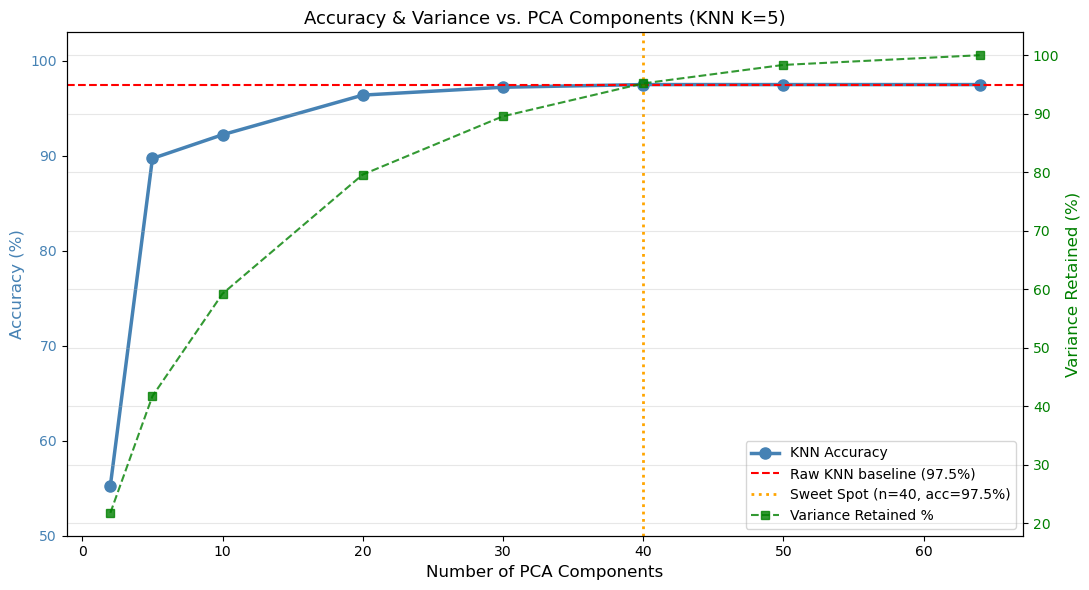

✅ Accuracy plot displayed!


In [8]:
# STEP 7: Plot Accuracy vs n_components (fixed)
n_vals   = [r['n_components'] for r in results]
acc_vals = [r['accuracy'] for r in results]
var_vals = [r['variance_retained'] for r in results]
best     = max(results, key=lambda r: r['accuracy'])

fig, ax1 = plt.subplots(figsize=(11, 6))

# Accuracy line
ax1.plot(n_vals, acc_vals, 'o-', color='steelblue', linewidth=2.5,
         markersize=8, label='KNN Accuracy')
ax1.axhline(y=raw_acc, color='red', linestyle='--', linewidth=1.5,
            label=f'Raw KNN baseline ({raw_acc:.1f}%)')
ax1.axvline(x=40, color='orange', linestyle=':', linewidth=2,
            label='Sweet Spot (n=40, acc=97.5%)')
ax1.set_xlabel("Number of PCA Components", fontsize=12)
ax1.set_ylabel("Accuracy (%)", color='steelblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_ylim([50, 103])

# Variance line on second Y axis
ax2 = ax1.twinx()
ax2.plot(n_vals, var_vals, 's--', color='green', linewidth=1.5,
         markersize=6, alpha=0.8, label='Variance Retained %')
ax2.set_ylabel("Variance Retained (%)", color='green', fontsize=12)
ax2.tick_params(axis='y', labelcolor='green')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=10)

plt.title("Accuracy & Variance vs. PCA Components (KNN K=5)", fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("✅ Accuracy plot displayed!")

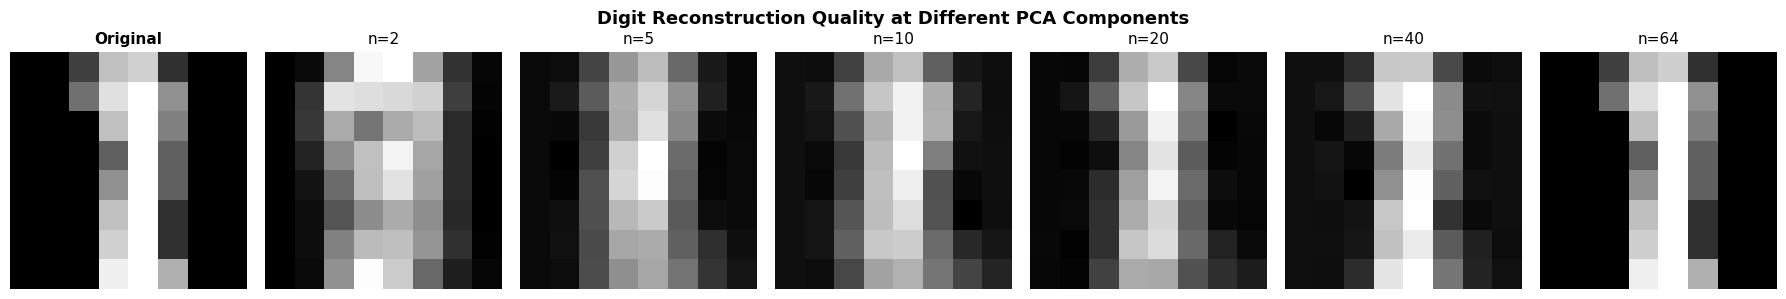

✅ Reconstruction images displayed!


In [9]:
# STEP 8: Reconstruct Digits at Different n_components
sample_idx = 10
sample = X_test_scaled[sample_idx].reshape(1, -1)
n_list = [2, 5, 10, 20, 40, 64]

fig, axes = plt.subplots(1, len(n_list) + 1, figsize=(18, 3))

# Show original
axes[0].imshow(X_test[sample_idx].reshape(8, 8), cmap='gray')
axes[0].set_title("Original", fontsize=11, fontweight='bold')
axes[0].axis('off')

# Show reconstructed at each n
for i, n in enumerate(n_list):
    pca = PCA(n_components=n)
    pca.fit(X_train_scaled)
    
    compressed     = pca.transform(sample)
    reconstructed  = pca.inverse_transform(compressed)
    reconstructed_unscaled = scaler.inverse_transform(reconstructed)
    
    axes[i+1].imshow(reconstructed_unscaled.reshape(8, 8), cmap='gray')
    axes[i+1].set_title(f"n={n}", fontsize=11)
    axes[i+1].axis('off')

plt.suptitle("Digit Reconstruction Quality at Different PCA Components", 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Reconstruction images displayed!")

In [10]:
# STEP 9: Final Report
print("=" * 60)
print("        FINAL REPORT: PCA + KNN Pipeline")
print("=" * 60)

print(f"\n{'Components':<12} {'Variance %':<15} {'Accuracy %':<12} {'Note'}")
print("-" * 60)

for r in results:
    if r['n_components'] == 40:
        note = "<-- SWEET SPOT"
    elif r['n_components'] == 2:
        note = "<-- Too compressed"
    elif r['n_components'] == 64:
        note = "<-- Full data"
    else:
        note = ""
    print(f"{r['n_components']:<12} {r['variance_retained']:<15} {r['accuracy']:<12} {note}")

print("-" * 60)

best     = max(results, key=lambda r: r['accuracy'])
gain     = best['accuracy'] - raw_acc
low      = min(results, key=lambda r: r['accuracy'])

print(f"\n  Raw KNN (no PCA):         {raw_acc:.2f}%")
print(f"  Best PCA + KNN:           {best['accuracy']:.2f}%  (n={best['n_components']})")
print(f"  Accuracy gain with PCA:   {gain:+.2f}%")
print(f"\n  Lowest accuracy (n=2):    {low['accuracy']:.2f}%")
print(f"  Highest accuracy (n=40):  {best['accuracy']:.2f}%")
print(f"  Total accuracy range:     {best['accuracy'] - low['accuracy']:.2f}%")

print(f"""
  CONCLUSION:
  - Sweet spot is n=40 components
  - Retains 95.18% variance using only 62.5% of features
  - PCA + KNN matches Raw KNN accuracy exactly
  - Below n=20, accuracy drops sharply
  - Above n=40, no further accuracy gain
""")
print("=" * 60)
print("  Project Complete!")
print("=" * 60)

        FINAL REPORT: PCA + KNN Pipeline

Components   Variance %      Accuracy %   Note
------------------------------------------------------------
2            21.77           55.28        <-- Too compressed
5            41.71           89.72        
10           59.23           92.22        
20           79.6            96.39        
30           89.56           97.22        
40           95.18           97.5         <-- SWEET SPOT
50           98.34           97.5         
64           100.0           97.5         <-- Full data
------------------------------------------------------------

  Raw KNN (no PCA):         97.50%
  Best PCA + KNN:           97.50%  (n=40)
  Accuracy gain with PCA:   +0.00%

  Lowest accuracy (n=2):    55.28%
  Highest accuracy (n=40):  97.50%
  Total accuracy range:     42.22%

  CONCLUSION:
  - Sweet spot is n=40 components
  - Retains 95.18% variance using only 62.5% of features
  - PCA + KNN matches Raw KNN accuracy exactly
  - Below n=20, accuracy dr